In [218]:
import os
import warnings

warnings.simplefilter(action="ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn import set_config

# transformers
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# pipelines
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score

# import xgboost

In [219]:
print("Working with these versions of libraries\n")
print("-" * 50)
print(f"sklearn version {sklearn.__version__}")

Working with these versions of libraries

--------------------------------------------------
sklearn version 1.8.0


In [220]:
os.getcwd()

'/Users/osvaldojavierhernandez/Documents/Nuclio Entregables'

In [221]:
df=pd.read_csv("/Users/osvaldojavierhernandez/Documents/Nuclio Entregables/sample_mmp.csv")

In [222]:
df.head()

,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections
0,8427007,f1cd864e97bae82bdf96523e1a539121,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1234.0,0,7.0,0,NaN,...,19951.0,0,NaN,0.0,0,0,0.0,0.0,11.0,1
1,8829090,fd5ba6f5b75325ec0423a6c67cc75942,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1282.0,0,7.0,0,NaN,...,48753.0,0,0.0,0.0,0,0,0.0,1.0,3.0,0
2,2731904,4e628391e7cc7c482fb3286f486dbd25,win8defender,1.1.15100.1,4.9.10586.1106,1.273.781.0,0,7.0,0,NaN,...,33111.0,1,0.0,0.0,1,1,0.0,0.0,15.0,0
3,1359513,270a2e9d028144a4df12a9e3da79fba5,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1639.0,0,7.0,0,NaN,...,48473.0,1,NaN,0.0,0,0,0.0,0.0,15.0,1
4,236059,06ca8fa8d32c2abdc5b3577d676b3269,win8defender,1.1.15200.1,4.18.1807.18075,1.275.511.0,0,7.0,0,NaN,...,4343.0,1,NaN,0.0,1,0,0.0,1.0,13.0,1


In [223]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 84 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   Unnamed: 0                                         500000 non-null  int64  
 1   MachineIdentifier                                  500000 non-null  str    
 2   ProductName                                        500000 non-null  str    
 3   EngineVersion                                      500000 non-null  str    
 4   AppVersion                                         500000 non-null  str    
 5   AvSigVersion                                       500000 non-null  str    
 6   IsBeta                                             500000 non-null  int64  
 7   RtpStateBitfield                                   498168 non-null  float64
 8   IsSxsPassiveMode                                   500000 non-null  int64  
 9   Defa

In [224]:
df.shape

(500000, 84)

In [225]:
X =df.copy()

In [226]:
# separamos nuestro dataset entre columnas numericas y object

numeric_columns = X.select_dtypes(include=np.number).columns.tolist()
object_columns = X.select_dtypes(exclude=np.number).columns.tolist()

assert (len(numeric_columns) + len(object_columns)) == X.shape[1], (
    "You have missed some columns"
)

In [227]:
print("Working with numeric columns: ", ", ".join(numeric_columns))
print("Working with categorical columns: ", ", ".join(object_columns))

Working with numeric columns:  Unnamed: 0, IsBeta, RtpStateBitfield, IsSxsPassiveMode, DefaultBrowsersIdentifier, AVProductStatesIdentifier, AVProductsInstalled, AVProductsEnabled, HasTpm, CountryIdentifier, CityIdentifier, OrganizationIdentifier, GeoNameIdentifier, LocaleEnglishNameIdentifier, OsBuild, OsSuite, IsProtected, AutoSampleOptIn, SMode, IeVerIdentifier, Firewall, UacLuaenable, Census_OEMNameIdentifier, Census_OEMModelIdentifier, Census_ProcessorCoreCount, Census_ProcessorManufacturerIdentifier, Census_ProcessorModelIdentifier, Census_PrimaryDiskTotalCapacity, Census_SystemVolumeTotalCapacity, Census_HasOpticalDiskDrive, Census_TotalPhysicalRAM, Census_InternalPrimaryDiagonalDisplaySizeInInches, Census_InternalPrimaryDisplayResolutionHorizontal, Census_InternalPrimaryDisplayResolutionVertical, Census_InternalBatteryNumberOfCharges, Census_OSBuildNumber, Census_OSBuildRevision, Census_OSInstallLanguageIdentifier, Census_OSUILocaleIdentifier, Census_IsPortableOperatingSystem, 

In [228]:
X.head().T

,0,1,2,3,4
Unnamed: 0,8427007,8829090,2731904,1359513,236059
MachineIdentifier,f1cd864e97bae82bdf96523e1a539121,fd5ba6f5b75325ec0423a6c67cc75942,4e628391e7cc7c482fb3286f486dbd25,270a2e9d028144a4df12a9e3da79fba5,06ca8fa8d32c2abdc5b3577d676b3269
ProductName,win8defender,win8defender,win8defender,win8defender,win8defender
EngineVersion,1.1.15100.1,1.1.15100.1,1.1.15100.1,1.1.15200.1,1.1.15200.1
AppVersion,4.18.1807.18075,4.18.1807.18075,4.9.10586.1106,4.18.1807.18075,4.18.1807.18075
...,...,...,...,...,...
Census_IsPenCapable,0,0,1,0,0
Census_IsAlwaysOnAlwaysConnectedCapable,0.0,0.0,0.0,0.0,0.0
Wdft_IsGamer,0.0,1.0,0.0,0.0,1.0
Wdft_RegionIdentifier,11.0,3.0,15.0,15.0,13.0


In [229]:
for col in X.select_dtypes(include='object').columns:
    print(f'\n{col}:')
    print(X[col].value_counts())
    print(f"Unique values: {X[col].nunique()}")
    


MachineIdentifier:
MachineIdentifier
f1cd864e97bae82bdf96523e1a539121    1
fd5ba6f5b75325ec0423a6c67cc75942    1
4e628391e7cc7c482fb3286f486dbd25    1
270a2e9d028144a4df12a9e3da79fba5    1
06ca8fa8d32c2abdc5b3577d676b3269    1
                                   ..
a739cacc292f3f1e745827c1ca6c6ada    1
a4c232d528d98343e8f1b73650da7b82    1
fd16cd542d660848d272e4552bcccb1e    1
fa0841f8f6147de7c3d287e05270ed42    1
7b45dc3537e17f16305c5983ca0a1cb9    1
Name: count, Length: 500000, dtype: int64
Unique values: 500000

ProductName:
ProductName
win8defender     494604
mse                5395
mseprerelease         1
Name: count, dtype: int64
Unique values: 3

EngineVersion:
EngineVersion
1.1.15200.1    216491
1.1.15100.1    205494
1.1.15000.2     14752
1.1.14901.4     11984
1.1.14600.4      9005
1.1.14800.3      7548
1.1.15300.6      6769
1.1.14104.0      5240
1.1.15300.5      3883
1.1.13504.0      3876
1.1.14700.5      2593
1.1.14500.5      2591
1.1.14405.2      1972
1.1.14306.0      1329
1

In [230]:
for col in X.select_dtypes(include='number').columns:
    print(f'\n{col} — Únicos: {X[col].nunique()}:')
    print(X[col].describe())
    print(f"Nulos: {X[col].isnull().sum()} ({X[col].isnull().sum()/len(X)*100:.1f}%)")


Unnamed: 0 — Únicos: 500000:
count    5.000000e+05
mean     4.458888e+06
std      2.575619e+06
min      2.000000e+00
25%      2.227692e+06
50%      4.461368e+06
75%      6.690936e+06
max      8.921471e+06
Name: Unnamed: 0, dtype: float64
Nulos: 0 (0.0%)

IsBeta — Únicos: 2:
count    500000.000000
mean          0.000002
std           0.001414
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: IsBeta, dtype: float64
Nulos: 0 (0.0%)

RtpStateBitfield — Únicos: 7:
count    498168.000000
mean          6.846207
std           1.023049
min           0.000000
25%           7.000000
50%           7.000000
75%           7.000000
max          35.000000
Name: RtpStateBitfield, dtype: float64
Nulos: 1832 (0.4%)

IsSxsPassiveMode — Únicos: 2:
count    500000.000000
mean          0.017242
std           0.130172
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: I

In [231]:
nulls = X.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)

print(f"Columnas con nulos: {len(nulls)} de {X.shape[1]}")
print(nulls.to_frame("nulos_absolutos").assign(
    porcentaje=lambda x: (x["nulos_absolutos"] / len(df) * 100).round(2)
))

Columnas con nulos: 44 de 84
                                                   nulos_absolutos  porcentaje
PuaMode                                                     499874       99.97
Census_ProcessorClass                                       497918       99.58
DefaultBrowsersIdentifier                                   475939       95.19
Census_IsFlightingInternal                                  415225       83.04
Census_InternalBatteryType                                  355603       71.12
Census_ThresholdOptIn                                       318104       63.62
Census_IsWIMBootEnabled                                     317666       63.53
SmartScreen                                                 178596       35.72
OrganizationIdentifier                                      154563       30.91
SMode                                                        29848        5.97
CityIdentifier                                               18240        3.65
Wdft_RegionIdentifier  

In [232]:
# Analizar correlación entre variables numéricas y el target
corr_target = X.select_dtypes(include=['number']).corr()['HasDetections'].sort_values(ascending=False)
print(corr_target)

HasDetections                                        1.000000e+00
AVProductStatesIdentifier                            1.161626e-01
Census_TotalPhysicalRAM                              6.043206e-02
Wdft_IsGamer                                         5.685800e-02
IsProtected                                          5.620321e-02
Census_ProcessorCoreCount                            5.606918e-02
Census_PrimaryDiskTotalCapacity                      4.804813e-02
RtpStateBitfield                                     4.030354e-02
Census_InternalPrimaryDiagonalDisplaySizeInInches    3.275656e-02
Census_InternalPrimaryDisplayResolutionHorizontal    3.141078e-02
Census_OSBuildNumber                                 3.003856e-02
OsBuild                                              2.440623e-02
Census_ProcessorModelIdentifier                      2.167108e-02
Census_HasOpticalDiskDrive                           2.007341e-02
Census_InternalBatteryNumberOfCharges                1.997974e-02
IeVerIdent

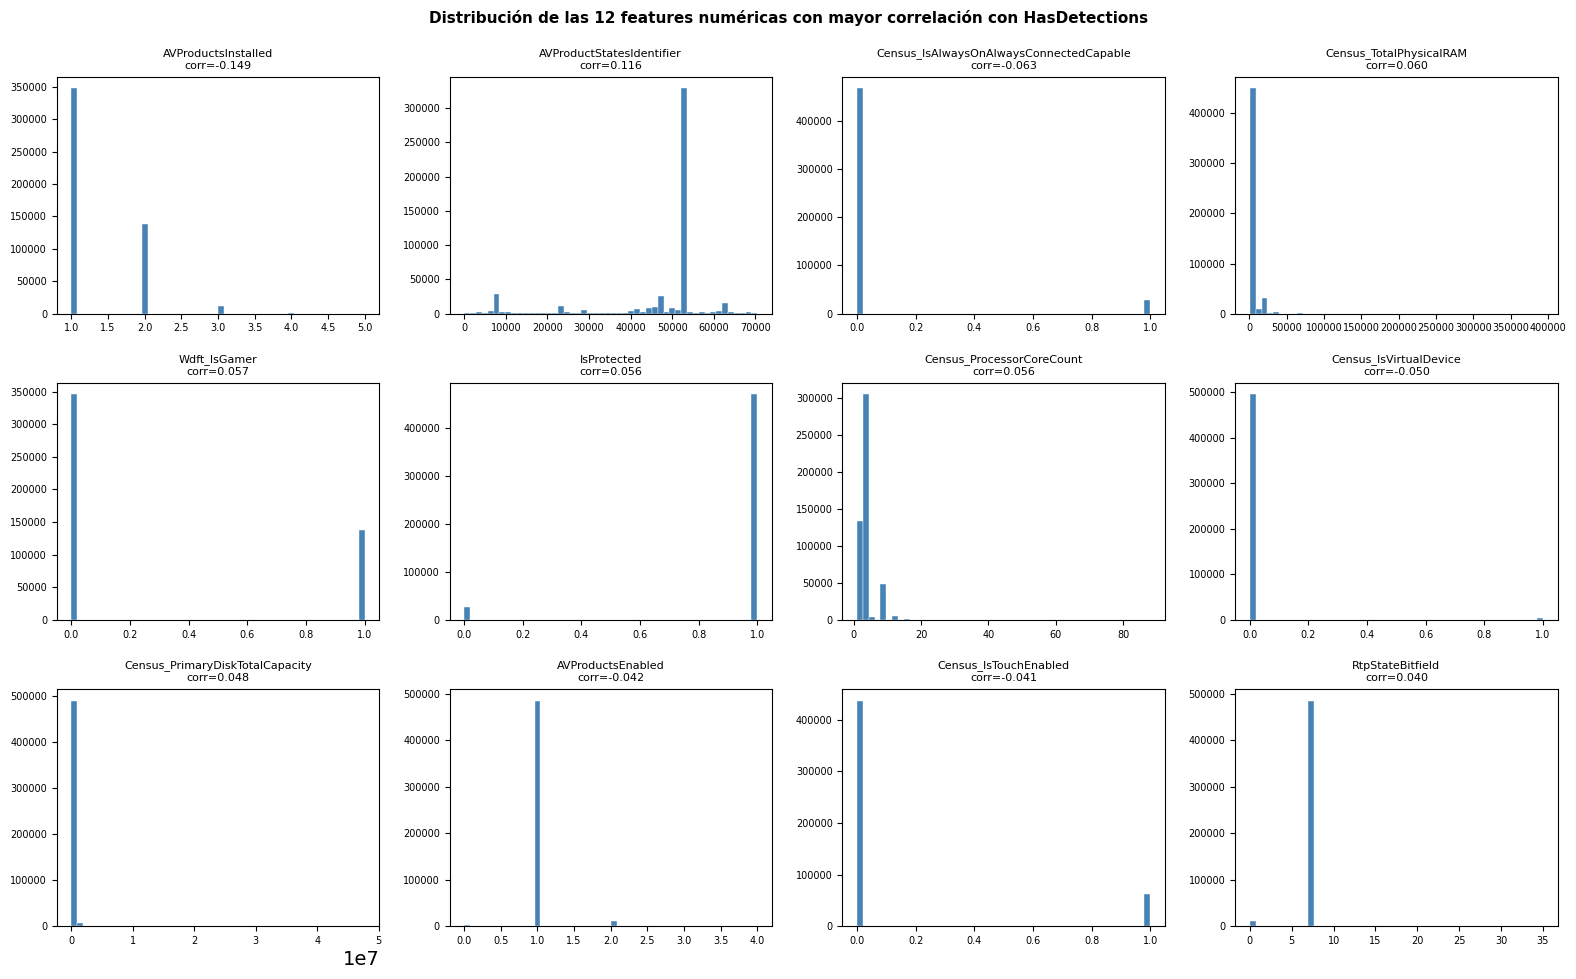

In [233]:

# Top features numéricas por correlación absoluta con el target
top_features = (
    corr_target
    .drop('HasDetections')
    .dropna()
    .abs()
    .sort_values(ascending=False)
    .head(12)
    .index.tolist()
)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[i].set_title(f'{col}\ncorr={corr_target[col]:.3f}', fontsize=8)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

plt.suptitle('Distribución de las 12 features numéricas con mayor correlación con HasDetections',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


In [234]:

# Tasa de detección de malware por cada variable categórica
cat_cols_eda = X.select_dtypes(include='object').columns.tolist()

for col in cat_cols_eda:
    print(f"\n{'='*60}")
    print(f"  {col}")
    print('='*60)
    pivot = (
        df[[col, 'HasDetections']]
        .pivot_table(index=col, values='HasDetections', aggfunc=[len, sum, np.mean])
        .sort_values(by=('mean', 'HasDetections'), ascending=False)
    )
    pivot.columns = ['total', 'con_malware', 'tasa_deteccion']
    print(pivot.head(10).to_string())



  MachineIdentifier
                                  total  con_malware  tasa_deteccion
MachineIdentifier                                                   
800cef3fef4461904da804aef4dd433b      1            1             1.0
8e1634bab4d4df8f5c1e308d293a21c8      1            1             1.0
8e1aeed8107a7a4204a3126315986ca3      1            1             1.0
8e1ac95551bf4442c970bb5b93749a81      1            1             1.0
8e1a8544782dcb70a1a699ccd8779fdf      1            1             1.0
8e1a566bbb5b0ad72a13022f2df15b90      1            1             1.0
8e1a09d5f1cc41629867223668a3e019      1            1             1.0
8e19818c96d489b181ff8c0c85ef30c5      1            1             1.0
8e1887edff5d3cfce62f4ffbc778f16d      1            1             1.0
8e18756ecdbe9f19f238f96667d27cd3      1            1             1.0

  ProductName
                total  con_malware  tasa_deteccion
ProductName                                       
win8defender   494604       247367

In [235]:
# Candidatas a eliminar, columnas con correlación casi nula (umbral ±0.001)
low_corr = corr_target[corr_target.abs() < 0.001].index.tolist()
print("Candidatas a eliminar por baja correlación:", low_corr)

Candidatas a eliminar por baja correlación: ['DefaultBrowsersIdentifier', 'Census_IsPortableOperatingSystem', 'Census_IsFlightingInternal', 'AutoSampleOptIn', 'Unnamed: 0', 'Census_ThresholdOptIn']


In [236]:
print(f"Nulos: {X['Census_IsPortableOperatingSystem'].isnull().sum()} ({X['Census_IsPortableOperatingSystem'].isnull().sum()/len(X)*100:.1f}%)")
print(X['Census_IsPortableOperatingSystem'].value_counts(dropna=False, normalize=True))

Nulos: 0 (0.0%)
Census_IsPortableOperatingSystem
0    0.999478
1    0.000522
Name: proportion, dtype: float64


In [237]:
print(f"Nulos: {X['AvSigVersion'].isnull().sum()} ({X['AvSigVersion'].isnull().sum()/len(X)*100:.1f}%)")
print(f"Valores únicos: {X['AvSigVersion'].nunique()}")
print(X['AvSigVersion'].value_counts(dropna=False).head(10))

Nulos: 0 (0.0%)
Valores únicos: 6455
AvSigVersion
1.273.1420.0    5771
1.263.48.0      5537
1.275.1140.0    5317
1.275.727.0     5214
1.273.371.0     4799
1.273.1826.0    4744
1.275.1244.0    4487
1.251.42.0      4258
1.275.1209.0    3787
1.273.810.0     3708
Name: count, dtype: int64


In [238]:
cols_to_drop = [
    'Unnamed: 0',                        # índice, no aporta información
    'AutoSampleOptIn',                   # correlación prácticamente 0 con target
    'Census_IsFlightingInternal',        # correlación prácticamente 0 con target
    'Census_ProcessorClass',             # sin varianza relevante
    'Census_IsPortableOperatingSystem',  # 99.95% es 0, sin varianza
    'SMode',                             # 99.96% es 0, sin varianza
    'Census_IsWIMBootEnabled',           # 63.5% nulos y único valor no nulo es 0
    'PuaMode',                           # >99% nulos
    'DefaultBrowsersIdentifier',         # 95% nulos
    'Census_ThresholdOptIn',             # 63.62% nulos
    'CityIdentifier',                    # alta cardinalidad (37,157 valores únicos)
    'Census_InternalBatteryType',        # alta cardinalidad
    'MachineIdentifier',                 # identificador único por dispositivo
    'OsBuildLab',                        # info redundante. Misma info en OsBuild, OsVer, Processor por separado
    'AvSigVersion',                      # alta cardinalidad (6,455), redundante con EngineVersion
    'Census_OSVersion',                  # redundante con Census_OSBuildNumber y OsVer
]

for col in cols_to_drop:
    if col in X.columns:
        print(f"{col}: {X[col].dtype}")
    else:
        print(f"{col}: NO EXISTE en X")

Unnamed: 0: int64
AutoSampleOptIn: int64
Census_IsFlightingInternal: float64
Census_ProcessorClass: str
Census_IsPortableOperatingSystem: int64
SMode: float64
Census_IsWIMBootEnabled: float64
PuaMode: str
DefaultBrowsersIdentifier: float64
Census_ThresholdOptIn: float64
CityIdentifier: float64
Census_InternalBatteryType: str
MachineIdentifier: str
OsBuildLab: str
AvSigVersion: str
Census_OSVersion: str


In [239]:
#hacemos el drop de las columnas candidatas a eliminar
X = X.drop(columns=cols_to_drop)
print(f"Shape después de eliminar: {X.shape}")

Shape después de eliminar: (500000, 68)


In [240]:
# Analizar nulos columnas restantes
nulls = X.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)

print(f"Columnas con nulos: {len(nulls)} de {X.shape[1]}")
print(nulls.to_frame("nulos_absolutos").assign(
    porcentaje=lambda x: (x["nulos_absolutos"] / len(df) * 100).round(2)
))

Columnas con nulos: 34 de 68
                                                   nulos_absolutos  porcentaje
SmartScreen                                                 178596       35.72
OrganizationIdentifier                                      154563       30.91
Wdft_RegionIdentifier                                        16950        3.39
Wdft_IsGamer                                                 16950        3.39
Census_InternalBatteryNumberOfCharges                        15038        3.01
Census_FirmwareManufacturerIdentifier                        10349        2.07
Census_FirmwareVersionIdentifier                              9061        1.81
Census_IsFlightsDisabled                                      8933        1.79
Census_OEMModelIdentifier                                     5764        1.15
Census_OEMNameIdentifier                                      5381        1.08
Firewall                                                      5162        1.03
Census_TotalPhysicalRAM

In [241]:
# Analizar columnas categóricas restantes
for col in X.select_dtypes(include='object').columns:
    print(f'\n{col}:')
    print(X[col].value_counts())
#    print(f"Unique values: {X[col].nunique()}")


ProductName:
ProductName
win8defender     494604
mse                5395
mseprerelease         1
Name: count, dtype: int64

EngineVersion:
EngineVersion
1.1.15200.1    216491
1.1.15100.1    205494
1.1.15000.2     14752
1.1.14901.4     11984
1.1.14600.4      9005
1.1.14800.3      7548
1.1.15300.6      6769
1.1.14104.0      5240
1.1.15300.5      3883
1.1.13504.0      3876
1.1.14700.5      2593
1.1.14500.5      2591
1.1.14405.2      1972
1.1.14306.0      1329
1.1.14202.0       840
1.1.14003.0       804
1.1.13303.0       516
1.1.13903.0       515
1.1.13804.0       513
1.1.13407.0       479
1.1.13601.0       420
1.1.12902.0       321
1.1.14305.0       270
1.1.13704.0       255
1.1.13701.0       255
1.1.13202.0       245
1.1.13103.0       235
1.1.13000.0       220
1.1.15000.1       138
1.1.12805.0       115
1.1.14901.3        71
1.1.14700.4        65
1.1.14700.3        61
1.1.14800.1        51
1.1.14500.2        19
1.1.14201.0        11
1.1.14303.0        10
1.1.12101.0         7
1.1.14103.

In [242]:
X.SmartScreen.value_counts(dropna=False)

SmartScreen
RequireAdmin    241594
NaN             178596
ExistsNotSet     58497
Off              10388
Warn              7530
Prompt            1950
Block             1274
off                 75
On                  53
&#x02;              20
&#x01;              14
on                   8
requireadmin         1
Name: count, dtype: int64

In [243]:
#limpiamos SmartScreen, que tiene valores inconsistentes y algunos nulos

valid_values = ['Requireadmin', 'Existsnotset', 'Off', 'Warn', 'Prompt', 'Block', 'On']
X['SmartScreen'] = X['SmartScreen'].str.strip().str.capitalize()
X.loc[~X['SmartScreen'].isin(valid_values), 'SmartScreen'] = np.nan
print(X['SmartScreen'].value_counts(dropna=False))

SmartScreen
Requireadmin    241595
NaN             178630
Existsnotset     58497
Off              10463
Warn              7530
Prompt            1950
Block             1274
On                  61
Name: count, dtype: int64


In [244]:

cols_to_categorical = [
    'OrganizationIdentifier',
    'GeoNameIdentifier',
    'CountryIdentifier',
    'LocaleEnglishNameIdentifier',
    'Census_OSInstallLanguageIdentifier',
    'Census_OSUILocaleIdentifier',
    'Census_OEMNameIdentifier',
    'Census_OEMModelIdentifier',
    'Census_ProcessorManufacturerIdentifier',
    'Census_FirmwareManufacturerIdentifier',
    'Census_FirmwareVersionIdentifier',
]

for col in cols_to_categorical:
    if col in X.columns:
        X[col] = X[col].astype(str).replace('nan', np.nan)

print(X.dtypes.value_counts())


str        34
float64    22
int64      12
Name: count, dtype: int64


In [245]:
X.shape

(500000, 68)

In [246]:

from sklearn.model_selection import train_test_split

TARGET = 'HasDetections'
X_clean = X.drop(columns=[TARGET])
y = X[TARGET]

# --- Feature Engineering (antes del split para evitar problemas de orden) ---

# 1. Ratio AV: proporción de antivirus habilitados sobre instalados
X_clean['av_enabled_ratio'] = X_clean['AVProductsEnabled'] / X_clean['AVProductsInstalled']

# 2. Resolución total de pantalla
X_clean['screen_resolution'] = (
    X_clean['Census_InternalPrimaryDisplayResolutionHorizontal'] *
    X_clean['Census_InternalPrimaryDisplayResolutionVertical']
)

# 3. Versión mayor de AppVersion
X_clean['app_version_major'] = pd.to_numeric(
    X_clean['AppVersion'].str.split('.').str[0], errors='coerce'
)

print(f"Shape tras FE: {X_clean.shape}")

# --- Split ---
X_train, X_temp, y_train, y_temp = train_test_split(X_clean, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train:      {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X_clean):.0%})")
print(f"Validation: {X_val.shape[0]:,} filas ({X_val.shape[0]/len(X_clean):.0%})")
print(f"Test:       {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X_clean):.0%})")


Shape tras FE: (500000, 70)
Train:      350,000 filas (70%)
Validation: 75,000 filas (15%)
Test:       75,000 filas (15%)


In [247]:
# Columnas numéricas y categóricas de X_train
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f"Numéricas: {len(num_cols)}")
print(num_cols)
print(f"\nCategóricas: {len(cat_cols)}")
print(cat_cols)


Numéricas: 36
['IsBeta', 'RtpStateBitfield', 'IsSxsPassiveMode', 'AVProductStatesIdentifier', 'AVProductsInstalled', 'AVProductsEnabled', 'HasTpm', 'OsBuild', 'OsSuite', 'IsProtected', 'IeVerIdentifier', 'Firewall', 'UacLuaenable', 'Census_ProcessorCoreCount', 'Census_ProcessorModelIdentifier', 'Census_PrimaryDiskTotalCapacity', 'Census_SystemVolumeTotalCapacity', 'Census_HasOpticalDiskDrive', 'Census_TotalPhysicalRAM', 'Census_InternalPrimaryDiagonalDisplaySizeInInches', 'Census_InternalPrimaryDisplayResolutionHorizontal', 'Census_InternalPrimaryDisplayResolutionVertical', 'Census_InternalBatteryNumberOfCharges', 'Census_OSBuildNumber', 'Census_OSBuildRevision', 'Census_IsFlightsDisabled', 'Census_IsSecureBootEnabled', 'Census_IsVirtualDevice', 'Census_IsTouchEnabled', 'Census_IsPenCapable', 'Census_IsAlwaysOnAlwaysConnectedCapable', 'Wdft_IsGamer', 'Wdft_RegionIdentifier', 'av_enabled_ratio', 'screen_resolution', 'app_version_major']

Categóricas: 34
['ProductName', 'EngineVersion', 

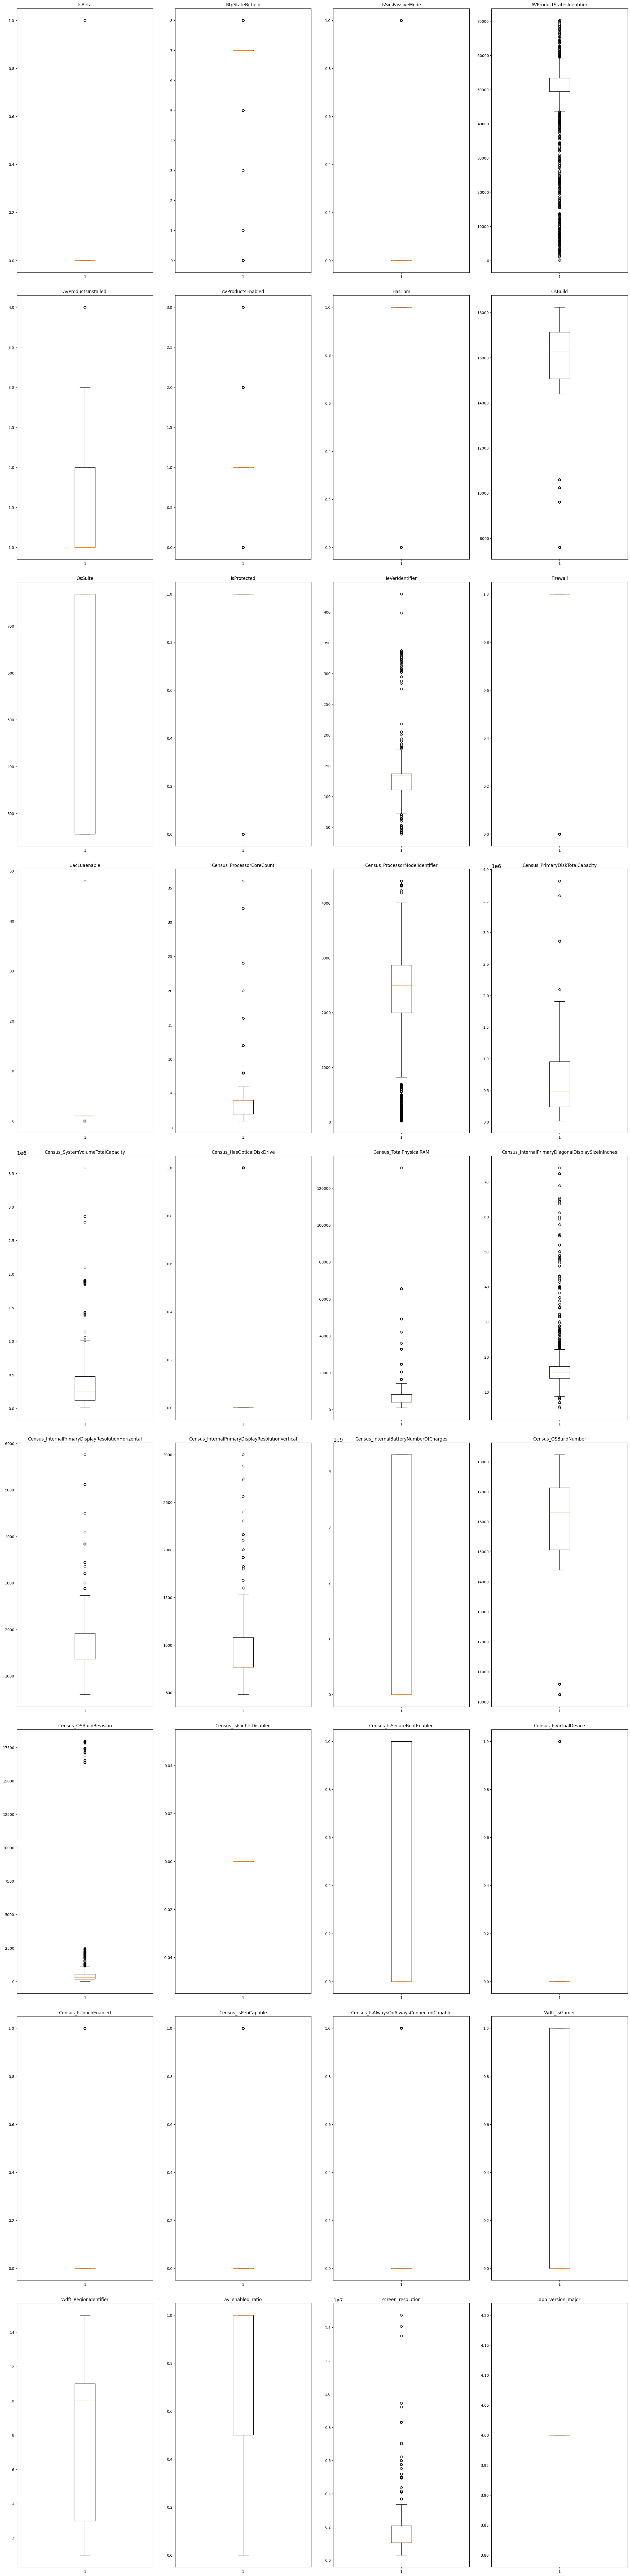

In [248]:
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 14  # tamaño global de letra

sample = X_train.sample(10000, random_state=42)

fig, axes = plt.subplots(nrows=len(num_cols)//4 + 1, ncols=4, figsize=(24, len(num_cols)*3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(sample[col].dropna())
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='both', labelsize=10)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Imputación de valores nulos

In [249]:

# Análisis de cardinalidad de columnas categóricas en train
cardinality = X_train[cat_cols].nunique().sort_values(ascending=False)

print("Cardinalidad de columnas categóricas:\n")
print(cardinality.to_string())

# Umbral: ≤ THRESHOLD categorías únicas → OHE | > THRESHOLD → alta cardinalidad
THRESHOLD_CARDINALITY = 10

cat_cols_low  = cardinality[cardinality <= THRESHOLD_CARDINALITY].index.tolist()  # pocas → OHE
cat_cols_high = cardinality[cardinality >  THRESHOLD_CARDINALITY].index.tolist()  # muchas → decidir

print(f"\n--- Umbral: {THRESHOLD_CARDINALITY} ---")
print(f"\nColumnas para OHE ({len(cat_cols_low)}):")
print(cat_cols_low)
print(f"\nColumnas con alta cardinalidad ({len(cat_cols_high)})  →  Frequency encoding / agrupación:")
print(cat_cols_high)


Cardinalidad de columnas categóricas:

Census_OEMModelIdentifier                 33394
Census_FirmwareVersionIdentifier          20836
Census_OEMNameIdentifier                   1397
Census_FirmwareManufacturerIdentifier       278
GeoNameIdentifier                           264
LocaleEnglishNameIdentifier                 223
CountryIdentifier                           222
AppVersion                                   93
Census_OSUILocaleIdentifier                  85
EngineVersion                                51
OrganizationIdentifier                       43
Census_OSInstallLanguageIdentifier           39
Census_ChassisTypeName                       32
Census_OSEdition                             20
Census_OSSkuName                             19
OsVer                                        16
Census_OSBranch                              15
Census_MDC2FormFactor                        11
OsPlatformSubRelease                          9
Census_PowerPlatformRoleName                  9
C

In [250]:

from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

# --- Frequency Encoder custom ---
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Reemplaza cada categoría por su frecuencia relativa aprendida en train.
    Categorías desconocidas en val/test se mapean a 0.
    Una columna de entrada → una columna de salida (no expande dimensiones).
    """
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = X.columns.astype(str).tolist()
        self.freq_maps_ = {
            col: X[col].value_counts(normalize=True).to_dict()
            for col in X.columns
        }
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].map(self.freq_maps_[col]).fillna(0)
        return X.values

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self)
        return np.array(self.feature_names_in_)

# --- Transformers ---

# Numéricas: mediana
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

# Baja cardinalidad (≤ THRESHOLD): OHE
cat_low_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Alta cardinalidad (> THRESHOLD): Frequency Encoding
cat_high_transformer = Pipeline(steps=[
    ('imputer',  SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder',  FrequencyEncoder()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num',      numeric_transformer,  num_cols),
        ('cat_low',  cat_low_transformer,  cat_cols_low),
        ('cat_high', cat_high_transformer, cat_cols_high),
    ],
    remainder='drop'
)

print(preprocessor)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['IsBeta', 'RtpStateBitfield',
                                  'IsSxsPassiveMode',
                                  'AVProductStatesIdentifier',
                                  'AVProductsInstalled', 'AVProductsEnabled',
                                  'HasTpm', 'OsBuild', 'OsSuite', 'IsProtected',
                                  'IeVerIdentifier', 'Firewall', 'UacLuaenable',
                                  'Census_ProcessorCoreCount',
                                  'Census_Process...
                                  'Census_OEMNameIdentifier',
                                  'Census_FirmwareManufacturerIdentifier',
                                  'GeoNameIdentifier',
                                  'LocaleEnglishNameIdentifier',
                  

In [251]:

# Preprocessing: fit_transform en train, transform en val/test
# Se usa solo el preprocesador (sin modelo) para evitar data leakage
X_train_transformed = preprocessor.fit_transform(X_train, y_train)
X_val_transformed   = preprocessor.transform(X_val)
X_test_transformed  = preprocessor.transform(X_test)

print(f"Train transformado : {X_train_transformed.shape}")
print(f"Val transformado   : {X_val_transformed.shape}")
print(f"Test transformado  : {X_test_transformed.shape}")


Train transformado : (350000, 148)
Val transformado   : (75000, 148)
Test transformado  : (75000, 148)


## Decision Tree

### Modelo base

=== Decision Tree — Validación ===

Accuracy : 0.6215
F1 Score : 0.6411

Verdaderos Negativos  (TN): 21,267
Falsos Positivos      (FP): 16,247
Falsos Negativos      (FN): 12,138
Verdaderos Positivos  (TP): 25,348


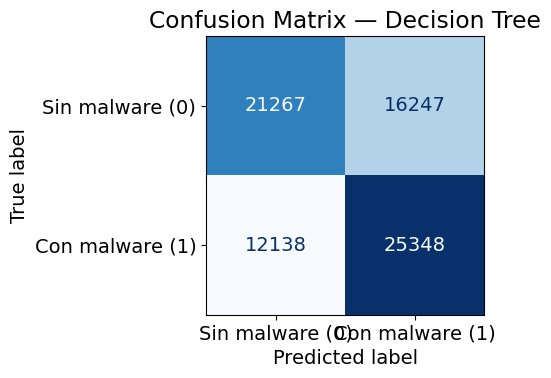

In [252]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Decision Tree como modelo base requerido por el enunciado
# max_depth=10 para evitar sobreajuste manteniendo capacidad predictiva
dt = DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced')
dt.fit(X_train_transformed, y_train)

y_pred_dt = dt.predict(X_val_transformed)

acc_dt = accuracy_score(y_val, y_pred_dt)
f1_dt  = f1_score(y_val, y_pred_dt)
cm_dt  = confusion_matrix(y_val, y_pred_dt)

print("=== Decision Tree — Validación ===\n")
print(f"Accuracy : {acc_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm_dt[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_dt[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm_dt[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm_dt[1,1]:,}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.show()


### Tuning de hiperparámetros — Decision Tree

In [253]:
from sklearn.model_selection import RandomizedSearchCV

# Submuestra para acelerar el tuning
sample_idx_dt = np.random.RandomState(42).choice(len(X_train_transformed), size=50_000, replace=False)
X_tune_dt = X_train_transformed[sample_idx_dt]
y_tune_dt  = y_train.iloc[sample_idx_dt]

param_dist_dt = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf' : [1, 5, 20],
    'max_features'     : [None, 'sqrt', 'log2'],
    'class_weight'     : ['balanced', None],
    'ccp_alpha'        : [0.0, 1e-4, 1e-3],
}

dt_search = RandomizedSearchCV(
    estimator           = DecisionTreeClassifier(random_state=42),
    param_distributions = param_dist_dt,
    n_iter              = 30,
    scoring             = 'f1',
    cv                  = 3,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1,
)
dt_search.fit(X_tune_dt, y_tune_dt)

print(f"Mejores parámetros: {dt_search.best_params_}")
print(f"Mejor F1 (CV):      {dt_search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejores parámetros: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 5, 'criterion': 'entropy', 'class_weight': 'balanced', 'ccp_alpha': 0.0}
Mejor F1 (CV):      0.6412


In [254]:
# Reentrenamos con los mejores parámetros sobre todo el train transformado
best_dt = DecisionTreeClassifier(**dt_search.best_params_, random_state=42)
best_dt.fit(X_train_transformed, y_train)

y_pred_dt_tuned = best_dt.predict(X_val_transformed)

acc_dt_tuned = accuracy_score(y_val, y_pred_dt_tuned)
f1_dt_tuned  = f1_score(y_val, y_pred_dt_tuned)
cm_dt_tuned  = confusion_matrix(y_val, y_pred_dt_tuned)

print("=== Decision Tree Tuneado - Validacion ===")
print()
print(f"Accuracy : {acc_dt_tuned:.4f}")
print(f"F1 Score : {f1_dt_tuned:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm_dt_tuned[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_dt_tuned[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm_dt_tuned[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm_dt_tuned[1,1]:,}")

=== Decision Tree Tuneado - Validacion ===

Accuracy : 0.6083
F1 Score : 0.6280

Verdaderos Negativos  (TN): 20,830
Falsos Positivos      (FP): 16,684
Falsos Negativos      (FN): 12,690
Verdaderos Positivos  (TP): 24,796


### Threshold tuning — Decision Tree

In [255]:
# Ajuste del umbral de clasificacion para reducir FN
# Criterio: minimizar FN (prioridad de negocio en detección de malware)
y_proba_dt = best_dt.predict_proba(X_val_transformed)[:, 1]

print(f"{'Threshold':<12} {'Accuracy':>10} {'F1':>10} {'FN':>10} {'FP':>10}")
print("-" * 55)

for threshold in [0.5, 0.45, 0.4, 0.35, 0.3, 0.25]:
    y_pred_t = (y_proba_dt >= threshold).astype(int)
    cm_t = confusion_matrix(y_val, y_pred_t)
    f1_t = f1_score(y_val, y_pred_t)
    print(f"{threshold:<12} {accuracy_score(y_val, y_pred_t):>10.4f} {f1_t:>10.4f} {cm_t[1,0]:>10,} {cm_t[0,1]:>10,}")

# Threshold elegido: 0.3 — minimiza FN (dispositivos infectados no detectados)
# En seguridad, un FN es más costoso que un FP
best_threshold_dt = 0.3
print(f"\nThreshold seleccionado: {best_threshold_dt} (criterio: minimizar FN)")


Threshold      Accuracy         F1         FN         FP
-------------------------------------------------------
0.5              0.6083     0.6280     12,690     16,684
0.45             0.6082     0.6344     11,985     17,403
0.4              0.5775     0.6782      4,093     27,596
0.35             0.5775     0.6782      4,093     27,596
0.3              0.5594     0.6773      2,800     30,248
0.25             0.5143     0.6706        399     36,031

Threshold seleccionado: 0.3 (criterio: minimizar FN)


In [256]:
# Evaluacion final DT con mejor threshold
THRESHOLD_DT = best_threshold_dt
y_pred_dt_final = (y_proba_dt >= THRESHOLD_DT).astype(int)
cm_dt_final = confusion_matrix(y_val, y_pred_dt_final)

print("=== Comparativa Decision Tree (validacion) ===")
print()
print(f"{"Modelo":<30} {"Accuracy":>10} {"F1":>10} {"FN":>10}")
print("-" * 62)
print(f"{"DT base (max_depth=10)":<30} {acc_dt:>10.4f} {f1_dt:>10.4f} {cm_dt[1,0]:>10,}")
print(f"{"DT tuneado":<30} {acc_dt_tuned:>10.4f} {f1_dt_tuned:>10.4f} {cm_dt_tuned[1,0]:>10,}")
print(f"{"DT tuneado + threshold":<30} {accuracy_score(y_val, y_pred_dt_final):>10.4f} {f1_score(y_val, y_pred_dt_final):>10.4f} {cm_dt_final[1,0]:>10,}")

=== Comparativa Decision Tree (validacion) ===

Modelo                           Accuracy         F1         FN
--------------------------------------------------------------
DT base (max_depth=10)             0.6215     0.6411     12,138
DT tuneado                         0.6083     0.6280     12,690
DT tuneado + threshold             0.5594     0.6773      2,800


### Feature Importance — Decision Tree

=== Top 20 features — Decision Tree ===

                                                                        feature  importance
                                              cat_low__SmartScreen_Existsnotset    0.519437
                                                       num__AVProductsInstalled    0.176673
                                                   num__Census_TotalPhysicalRAM    0.068929
                                                 num__AVProductStatesIdentifier    0.064638
                                                                    cat_high__9    0.062806
                                                              num__Wdft_IsGamer    0.036293
                                                                    cat_high__7    0.019344
                         num__Census_InternalPrimaryDiagonalDisplaySizeInInches    0.018187
                                                         cat_low__Processor_x86    0.009633
                                       

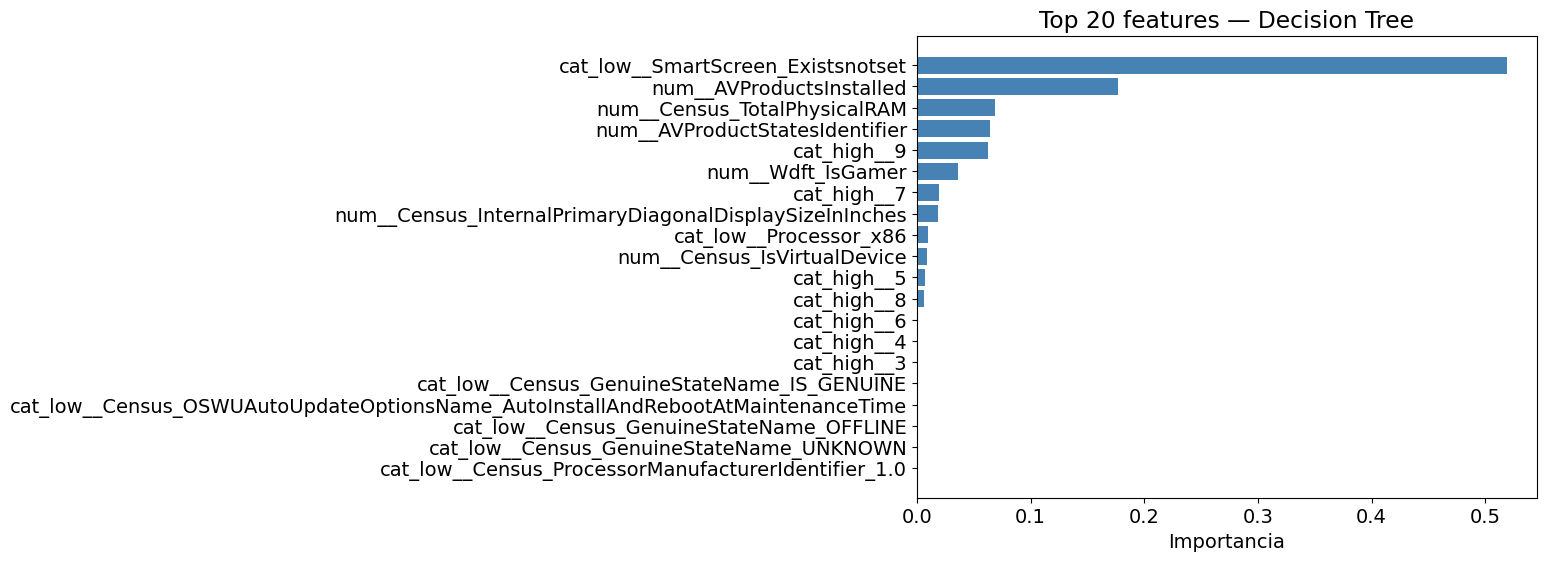

In [257]:

# Feature importance del Decision Tree tuneado
# Con OHE, los nombres de columnas los obtenemos del preprocessor
feature_names_dt = preprocessor.get_feature_names_out().tolist()

fi_dt = pd.Series(best_dt.feature_importances_, index=feature_names_dt).sort_values(ascending=False)
fi_dt_df = fi_dt.reset_index()
fi_dt_df.columns = ['feature', 'importance']

print("=== Top 20 features — Decision Tree ===\n")
print(fi_dt_df.head(20).to_string(index=False))

# Plot
top_n = 20
fi_dt_top = fi_dt_df.head(top_n)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_dt_top['feature'][::-1], fi_dt_top['importance'][::-1], color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} features — Decision Tree')
plt.tight_layout()
plt.show()


### Evaluación final en Test — Decision Tree

=== Decision Tree — Evaluación Final en Test ===

Threshold usado    : 0.3
Accuracy           : 0.5616
F1 Score           : 0.6798

Verdaderos Negativos  (TN): 7,213
Falsos Positivos      (FP): 30,165
Falsos Negativos      (FN): 2,717
Verdaderos Positivos  (TP): 34,905


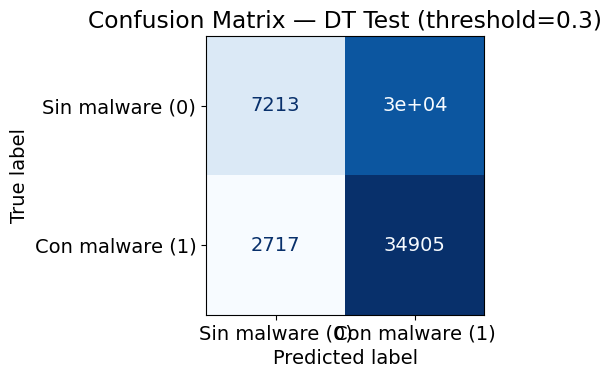

In [258]:

# Evaluación final en test — solo se ejecuta una vez
# Usamos el mejor threshold encontrado en validación
y_proba_dt_test = best_dt.predict_proba(X_test_transformed)[:, 1]
y_pred_dt_test  = (y_proba_dt_test >= THRESHOLD_DT).astype(int)

acc_dt_test = accuracy_score(y_test, y_pred_dt_test)
f1_dt_test  = f1_score(y_test, y_pred_dt_test)
cm_dt_test  = confusion_matrix(y_test, y_pred_dt_test)

print("=== Decision Tree — Evaluación Final en Test ===\n")
print(f"Threshold usado    : {THRESHOLD_DT}")
print(f"Accuracy           : {acc_dt_test:.4f}")
print(f"F1 Score           : {f1_dt_test:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm_dt_test[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_dt_test[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm_dt_test[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm_dt_test[1,1]:,}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_dt_test, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — DT Test (threshold={THRESHOLD_DT})')
plt.tight_layout()
plt.show()


## Random Forest

### Modelo base

=== Random Forest base — Validación ===

Accuracy : 0.6363
F1 Score : 0.6243

Verdaderos Negativos  (TN): 25,058
Falsos Positivos      (FP): 12,456
Falsos Negativos      (FN): 14,820
Verdaderos Positivos  (TP): 22,666


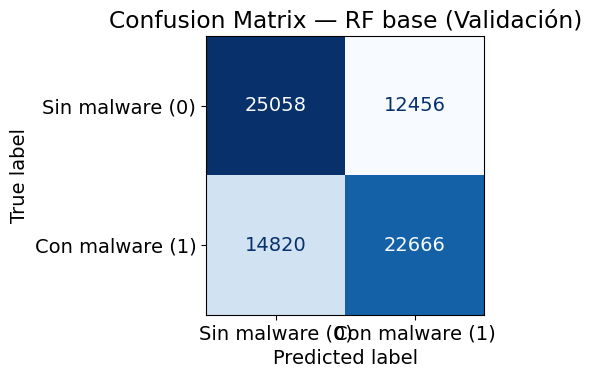

In [259]:

from sklearn.ensemble import RandomForestClassifier

# RF base: 100 árboles, sin tunear — punto de partida comparable al DT
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train_transformed, y_train)

y_pred_val = rf_base.predict(X_val_transformed)

acc = accuracy_score(y_val, y_pred_val)
f1  = f1_score(y_val, y_pred_val)
cm  = confusion_matrix(y_val, y_pred_val)

print("=== Random Forest base — Validación ===\n")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm[1,1]:,}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — RF base (Validación)')
plt.tight_layout()
plt.show()


### Tuning de hiperparámetros

In [260]:

from sklearn.model_selection import RandomizedSearchCV

# Submuestra reducida para acelerar el tuning
sample_idx = np.random.RandomState(42).choice(len(X_train_transformed), size=50_000, replace=False)
X_tune = X_train_transformed[sample_idx]
y_tune = y_train.iloc[sample_idx]

param_dist = {
    'n_estimators'     : [100],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf' : [1, 4],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : [None, 'balanced'],
}

rf_search = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter              = 10,
    scoring             = 'recall',
    cv                  = 2,
    random_state        = 42,
    verbose             = 2,
    n_jobs              = -1,
)

rf_search.fit(X_tune, y_tune)

print(f"\nMejores parámetros: {rf_search.best_params_}")
print(f"Mejor recall (CV) : {rf_search.best_score_:.4f}")


Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   2.6s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   2.8s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   2.7s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   2.9s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.7s
[CV] END class_weight=balanced, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.5s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_

=== Evaluación tras Tuning (Validación) ===

Accuracy : 0.6260
F1 Score : 0.6426

Verdaderos Negativos  (TN): 21,744
Falsos Positivos      (FP): 15,770
Falsos Negativos      (FN): 12,277
Verdaderos Positivos  (TP): 25,209


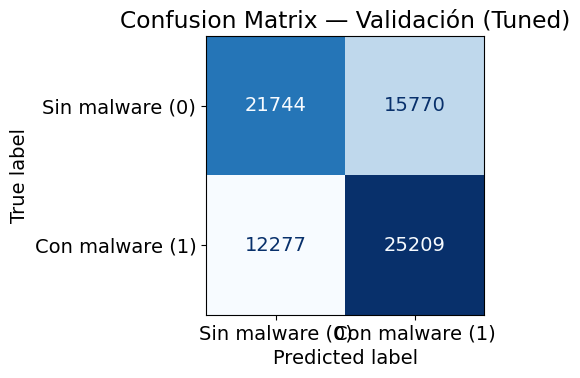

In [261]:

# Reentrenamos con los mejores parámetros sobre todo el train transformado
best_rf = RandomForestClassifier(**rf_search.best_params_, random_state=42, n_jobs=-1)
best_rf.fit(X_train_transformed, y_train)

# Evaluación en validación
y_pred_val_tuned = best_rf.predict(X_val_transformed)

acc_tuned = accuracy_score(y_val, y_pred_val_tuned)
f1_tuned  = f1_score(y_val, y_pred_val_tuned)
cm_tuned  = confusion_matrix(y_val, y_pred_val_tuned)

print("=== Evaluación tras Tuning (Validación) ===\n")
print(f"Accuracy : {acc_tuned:.4f}")
print(f"F1 Score : {f1_tuned:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm_tuned[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_tuned[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm_tuned[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm_tuned[1,1]:,}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Validación (Tuned)')
plt.tight_layout()
plt.show()


In [262]:

from sklearn.dummy import DummyClassifier

# Baseline: predice siempre la clase más frecuente
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_transformed, y_train)
y_pred_dummy = dummy.predict(X_val_transformed)

acc_dummy = accuracy_score(y_val, y_pred_dummy)
f1_dummy  = f1_score(y_val, y_pred_dummy)

# Tabla comparativa: Dummy vs Decision Tree vs RF base vs RF tuneado
print("=== Comparativa de modelos ===\n")
print(f"{'Modelo':<22} {'Accuracy':>10} {'F1':>10}")
print("-" * 44)
print(f"{'Dummy (baseline)':<22} {acc_dummy:>10.4f} {f1_dummy:>10.4f}")
print(f"{'Decision Tree':<22} {acc_dt:>10.4f} {f1_dt:>10.4f}")
print(f"{'RF base':<22} {acc:>10.4f} {f1:>10.4f}")
print(f"{'RF tuneado':<22} {acc_tuned:>10.4f} {f1_tuned:>10.4f}")


=== Comparativa de modelos ===

Modelo                   Accuracy         F1
--------------------------------------------
Dummy (baseline)           0.5002     0.0000
Decision Tree              0.6215     0.6411
RF base                    0.6363     0.6243
RF tuneado                 0.6260     0.6426


### Feature Importance

In [263]:

# Con OHE, los nombres reales de columnas los da el preprocessor
feature_names = preprocessor.get_feature_names_out().tolist()

importances = best_rf.feature_importances_
fi_df = pd.DataFrame({
    'feature'   : feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(fi_df.head(20).to_string(index=False))


                                               feature  importance
                     cat_low__SmartScreen_Existsnotset    0.263830
                        num__AVProductStatesIdentifier    0.084657
                              num__AVProductsInstalled    0.076897
                                 num__av_enabled_ratio    0.062321
                     cat_low__SmartScreen_Requireadmin    0.048349
                                           cat_high__9    0.047993
                          num__Census_TotalPhysicalRAM    0.024354
                                           cat_high__7    0.024093
                          cat_low__SmartScreen_Missing    0.021835
num__Census_InternalPrimaryDiagonalDisplaySizeInInches    0.018546
                  num__Census_PrimaryDiskTotalCapacity    0.018478
                 num__Census_SystemVolumeTotalCapacity    0.015734
                                     num__Wdft_IsGamer    0.012180
                  num__Census_ProcessorModelIdentifier    0.01

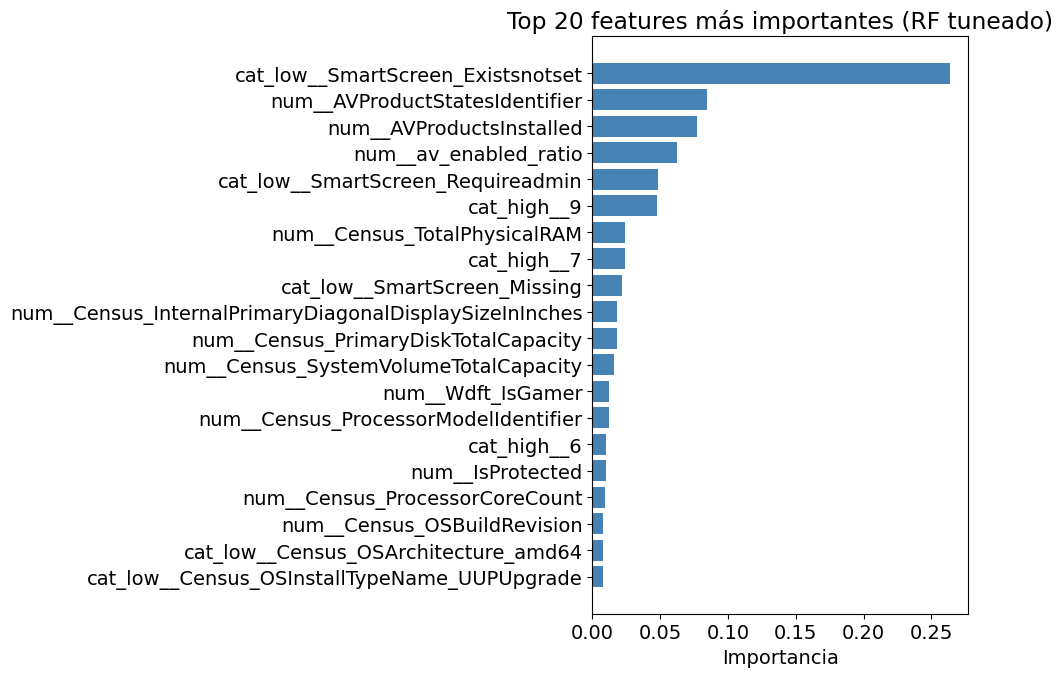


Features con importancia < 0.001: 82
['cat_low__Census_OSInstallTypeName_Reset', 'num__Census_IsSecureBootEnabled', 'cat_low__OsPlatformSubRelease_rs3', 'cat_low__Census_GenuineStateName_OFFLINE', 'cat_low__Census_PrimaryDiskTypeName_UNKNOWN', 'cat_low__SkuEdition_Home', 'cat_low__SmartScreen_Off', 'num__OsSuite', 'cat_low__Census_PowerPlatformRoleName_Mobile', 'cat_low__Census_OSInstallTypeName_Refresh', 'cat_low__Census_GenuineStateName_INVALID_LICENSE', 'cat_low__Census_OSInstallTypeName_Other', 'cat_low__SkuEdition_Pro', 'num__HasTpm', 'cat_low__Platform_windows10', 'cat_low__OsPlatformSubRelease_windows7', 'cat_low__SmartScreen_Warn', 'cat_high__15', 'cat_low__OsPlatformSubRelease_rs1', 'cat_low__Census_OSInstallTypeName_Upgrade', 'cat_low__Census_ProcessorManufacturerIdentifier_5.0', 'cat_low__OsPlatformSubRelease_th2', 'cat_low__Census_FlightRing_Retail', 'cat_low__Census_FlightRing_NOT_SET', 'cat_low__OsPlatformSubRelease_th1', 'cat_low__OsPlatformSubRelease_rs2', 'cat_low__Pr

In [264]:

# Plot top 20 features
top_n = 20
fi_top = fi_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi_top['feature'][::-1], fi_top['importance'][::-1], color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} features más importantes (RF tuneado)')
plt.tight_layout()
plt.show()

# Features con importancia casi nula (candidatas a eliminar)
threshold = 0.001
low_importance = fi_df[fi_df['importance'] < threshold]
print(f"\nFeatures con importancia < {threshold}: {len(low_importance)}")
print(low_importance['feature'].tolist())


In [265]:

# Eliminamos features con baja importancia y sin señal real
cols_to_drop_fi = ['HasTpm', 'Firewall', 'ProductName', 'IsBeta', 'Census_IsFlightsDisabled', 'UacLuaenable']

X_clean2 = X_clean.drop(columns=cols_to_drop_fi)
print(f"Shape anterior: {X_clean.shape}")
print(f"Shape nuevo   : {X_clean2.shape}")

# Nuevo split
X_train2, X_temp2, y_train2, y_temp2 = train_test_split(X_clean2, y, test_size=0.30, random_state=42)
X_val2, X_test2, y_val2, y_test2     = train_test_split(X_temp2, y_temp2, test_size=0.50, random_state=42)

# Nuevas listas de columnas
num_cols2 = X_train2.select_dtypes(include='number').columns.tolist()
cat_cols2 = X_train2.select_dtypes(include='object').columns.tolist()

print(f"\nNuméricas: {len(num_cols2)}")
print(f"Categóricas: {len(cat_cols2)}")


Shape anterior: (500000, 70)
Shape nuevo   : (500000, 64)

Numéricas: 31
Categóricas: 33


In [266]:

# Nuevo pipeline con las features reducidas
numeric_transformer2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer2, num_cols2),
        ('cat', categorical_transformer2, cat_cols2),
    ],
    remainder='drop'
)

# fit_transform en train, transform en val y test
X_train2_t = preprocessor2.fit_transform(X_train2, y_train2)
X_val2_t   = preprocessor2.transform(X_val2)
X_test2_t  = preprocessor2.transform(X_test2)

print(f"Train: {X_train2_t.shape}")
print(f"Val  : {X_val2_t.shape}")
print(f"Test : {X_test2_t.shape}")

# Reentrenamos con los mejores parámetros del tuning
best_rf2 = RandomForestClassifier(**rf_search.best_params_, random_state=42, n_jobs=-1)
best_rf2.fit(X_train2_t, y_train2)
print("\nEntrenamiento completado")


Train: (350000, 64)
Val  : (75000, 64)
Test : (75000, 64)

Entrenamiento completado


=== Comparativa final ===

Modelo                           Accuracy         F1
----------------------------------------------------
Dummy (baseline)                   0.5002     0.0000
RF base                            0.6329     0.6216
RF tuneado                         0.6275     0.6456
RF tuneado + feature sel.          0.6249     0.6429

Verdaderos Negativos  (TN): 21,540
Falsos Positivos      (FP): 15,974
Falsos Negativos      (FN): 12,159
Verdaderos Positivos  (TP): 25,327


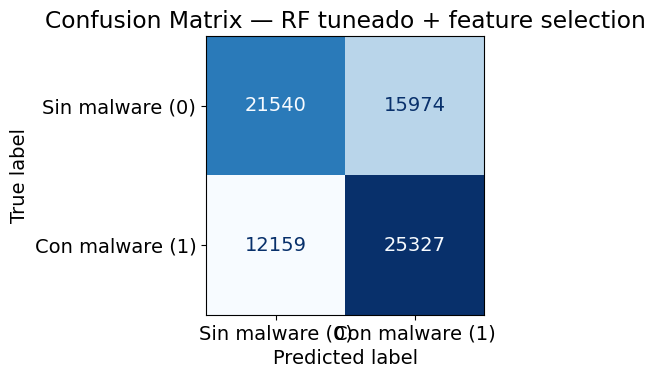

In [267]:

# Evaluación del modelo con features reducidas
y_pred_val2 = best_rf2.predict(X_val2_t)

acc2 = accuracy_score(y_val2, y_pred_val2)
f1_2 = f1_score(y_val2, y_pred_val2)
cm2  = confusion_matrix(y_val2, y_pred_val2)

print("=== Comparativa final ===\n")
print(f"{'Modelo':<30} {'Accuracy':>10} {'F1':>10}")
print("-" * 52)
print(f"{'Dummy (baseline)':<30} {0.5002:>10.4f} {0.0000:>10.4f}")
print(f"{'RF base':<30} {0.6329:>10.4f} {0.6216:>10.4f}")
print(f"{'RF tuneado':<30} {0.6275:>10.4f} {0.6456:>10.4f}")
print(f"{'RF tuneado + feature sel.':<30} {acc2:>10.4f} {f1_2:>10.4f}")

print(f"\nVerdaderos Negativos  (TN): {cm2[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm2[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm2[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm2[1,1]:,}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — RF tuneado + feature selection')
plt.tight_layout()
plt.show()


## Feature Engineering

In [268]:
# Feature Engineering movido a la celda del split (antes del train_test_split)

In [269]:
# Correlación de las nuevas features con el target
new_features = ['av_enabled_ratio', 'screen_resolution', 'app_version_major']
corr_new = pd.concat([X_clean[new_features], y], axis=1).corr()['HasDetections'].drop('HasDetections')
print("Correlación nuevas features con HasDetections:")
print(corr_new.sort_values(ascending=False))

Correlación nuevas features con HasDetections:
av_enabled_ratio     0.138260
screen_resolution    0.017387
app_version_major         NaN
Name: HasDetections, dtype: float64


### Evaluación final en Test

=== Evaluación FINAL en Test ===

Accuracy : 0.6269
F1 Score : 0.6452

Verdaderos Negativos  (TN): 21,584
Falsos Positivos      (FP): 15,794
Falsos Negativos      (FN): 12,185
Verdaderos Positivos  (TP): 25,437


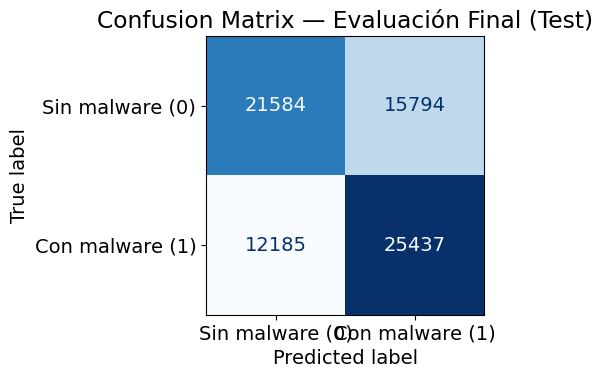

In [270]:

# Evaluación final — solo se ejecuta una vez con el mejor modelo (RF tuneado)
y_pred_test = best_rf.predict(X_test_transformed)

acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test)
cm_test  = confusion_matrix(y_test, y_pred_test)

print("=== Evaluación FINAL en Test ===\n")
print(f"Accuracy : {acc_test:.4f}")
print(f"F1 Score : {f1_test:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm_test[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_test[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm_test[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm_test[1,1]:,}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Evaluación Final (Test)')
plt.tight_layout()
plt.show()


### Exploración de max_depth

In [271]:

# Exploración de max_depth manteniendo el resto de parámetros del mejor modelo
best_params = rf_search.best_params_.copy()

print(f"{'max_depth':<12} {'Accuracy':>10} {'F1':>10} {'FN':>10}")
print("-" * 45)

for depth in [10, 15, 20, 25, None]:
    params = {**best_params, 'max_depth': depth}
    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    rf.fit(X_train_transformed, y_train)
    y_pred = rf.predict(X_val_transformed)
    cm = confusion_matrix(y_val, y_pred)
    fn = cm[1, 0]
    print(f"{str(depth):<12} {accuracy_score(y_val, y_pred):>10.4f} {f1_score(y_val, y_pred):>10.4f} {fn:>10,}")


max_depth      Accuracy         F1         FN
---------------------------------------------
10               0.6260     0.6426     12,277
15               0.6364     0.6446     12,756
20               0.6424     0.6444     13,184
25               0.6431     0.6413     13,551
None             0.6421     0.6332     14,314


### Threshold tuning

In [272]:

# Threshold tuning: ajustamos el umbral de clasificación para reducir FN
y_proba = best_rf.predict_proba(X_val_transformed)[:, 1]

print(f"{'Threshold':<12} {'Accuracy':>10} {'F1':>10} {'FN':>10} {'FP':>10}")
print("-" * 55)

for threshold in [0.5, 0.45, 0.4, 0.35, 0.3]:
    y_pred_t = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_val, y_pred_t)
    print(f"{threshold:<12} {accuracy_score(y_val, y_pred_t):>10.4f} {f1_score(y_val, y_pred_t):>10.4f} {cm[1,0]:>10,} {cm[0,1]:>10,}")


Threshold      Accuracy         F1         FN         FP
-------------------------------------------------------
0.5              0.6260     0.6426     12,277     15,770
0.45             0.6153     0.6712      8,036     20,815
0.4              0.5937     0.6839      4,519     25,954
0.35             0.5581     0.6816      2,012     31,129
0.3              0.5191     0.6724        468     35,597


### Evaluación final en Test (threshold=0.45)

=== Evaluación FINAL en Test (threshold=0.45) ===

Accuracy : 0.6178
F1 Score : 0.6749

Verdaderos Negativos  (TN): 16,582
Falsos Positivos      (FP): 20,796
Falsos Negativos      (FN): 7,870
Verdaderos Positivos  (TP): 29,752


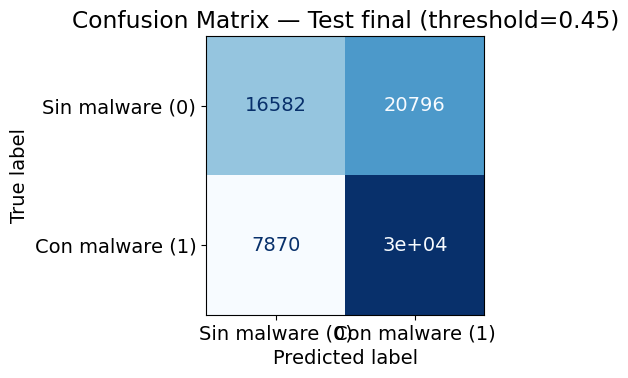


=== Comparativa completa ===

Modelo                                Accuracy         F1         FN
--------------------------------------------------------------------
Dummy (baseline)                        0.5002     0.0000          —
RF base (threshold=0.5)                 0.6329     0.6216     14,873
RF tuneado (threshold=0.5)              0.6275     0.6456     12,038
RF tuneado + FE (threshold=0.45)        0.6178     0.6749      7,870


In [273]:

THRESHOLD = 0.45

# Probabilidades en test
y_proba_test = best_rf.predict_proba(X_test_transformed)[:, 1]
y_pred_test_t = (y_proba_test >= THRESHOLD).astype(int)

acc_final  = accuracy_score(y_test, y_pred_test_t)
f1_final   = f1_score(y_test, y_pred_test_t)
cm_final   = confusion_matrix(y_test, y_pred_test_t)

print(f"=== Evaluación FINAL en Test (threshold={THRESHOLD}) ===\n")
print(f"Accuracy : {acc_final:.4f}")
print(f"F1 Score : {f1_final:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm_final[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_final[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm_final[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm_final[1,1]:,}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Test final (threshold={THRESHOLD})')
plt.tight_layout()
plt.show()

# Comparativa completa
print("\n=== Comparativa completa ===\n")
print(f"{'Modelo':<35} {'Accuracy':>10} {'F1':>10} {'FN':>10}")
print("-" * 68)
print(f"{'Dummy (baseline)':<35} {0.5002:>10.4f} {0.0000:>10.4f} {'—':>10}")
print(f"{'RF base (threshold=0.5)':<35} {0.6329:>10.4f} {0.6216:>10.4f} {14873:>10,}")
print(f"{'RF tuneado (threshold=0.5)':<35} {0.6275:>10.4f} {0.6456:>10.4f} {12038:>10,}")
print(f"{'RF tuneado + FE (threshold=0.45)':<35} {acc_final:>10.4f} {f1_final:>10.4f} {cm_final[1,0]:>10,}")


## LightGBM

In [274]:

from lightgbm import LGBMClassifier

# Entrenamiento LightGBM con los mismos datos transformados
lgbm = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgbm.fit(X_train_transformed, y_train)

# Evaluación en validación con threshold=0.5
y_pred_lgbm = lgbm.predict(X_val_transformed)
acc_lgbm = accuracy_score(y_val, y_pred_lgbm)
f1_lgbm  = f1_score(y_val, y_pred_lgbm)
cm_lgbm  = confusion_matrix(y_val, y_pred_lgbm)

print("=== LightGBM (threshold=0.5) — Validación ===\n")
print(f"Accuracy : {acc_lgbm:.4f}")
print(f"F1 Score : {f1_lgbm:.4f}")
print(f"FN       : {cm_lgbm[1,0]:,}")
print(f"FP       : {cm_lgbm[0,1]:,}")

# Comparativa con el mejor RF
print("\n=== Comparativa ===\n")
print(f"{'Modelo':<35} {'Accuracy':>10} {'F1':>10} {'FN':>10}")
print("-" * 68)
print(f"{'RF tuneado + FE (0.45)':<35} {0.6206:>10.4f} {0.6734:>10.4f} {8290:>10,}")
print(f"{'LightGBM (0.5)':<35} {acc_lgbm:>10.4f} {f1_lgbm:>10.4f} {cm_lgbm[1,0]:>10,}")


=== LightGBM (threshold=0.5) — Validación ===

Accuracy : 0.6469
F1 Score : 0.6430
FN       : 13,634
FP       : 12,851

=== Comparativa ===

Modelo                                Accuracy         F1         FN
--------------------------------------------------------------------
RF tuneado + FE (0.45)                  0.6206     0.6734      8,290
LightGBM (0.5)                          0.6469     0.6430     13,634


## Comparativa Final — Curva ROC

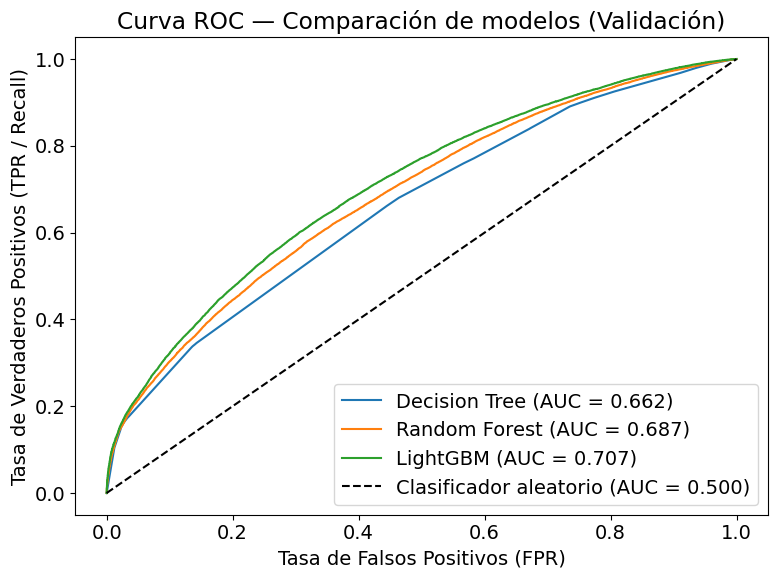

In [275]:
from sklearn.metrics import roc_curve, auc

# Probabilidades de clase positiva (malware) en validación
y_prob_dt   = best_dt.predict_proba(X_val_transformed)[:, 1]
y_prob_rf   = best_rf.predict_proba(X_val_transformed)[:, 1]
y_prob_lgbm = lgbm.predict_proba(X_val_transformed)[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
for name, y_prob in [
    ("Decision Tree", y_prob_dt),
    ("Random Forest", y_prob_rf),
    ("LightGBM",      y_prob_lgbm),
]:
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC = 0.500)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
ax.set_title('Curva ROC — Comparación de modelos (Validación)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Conclusiones

### Tarea
Clasificación binaria para detectar malware en dispositivos Windows (`HasDetections`: 0 = sin malware, 1 = con malware). Dataset balanceado (~50% por clase, ~500 k dispositivos).

### Modelo principal: Decision Tree

El Decision Tree tuneado es el modelo central de este trabajo. Tras optimizar sus hiperparámetros con `RandomizedSearchCV` y ajustar el umbral de clasificación, los resultados en validación son:

| Modelo | Accuracy | F1 | FN | FP |
|---|---|---|---|---|
| DummyClassifier (baseline) | 0.5002 | 0.0000 | — | — |
| DT base (`max_depth=10`) | 0.6215 | 0.6411 | — | — |
| DT tuneado (`threshold=0.50`) | 0.6083 | 0.6280 | 12,690 | 16,684 |
| DT tuneado (`threshold=0.45`) | 0.6082 | 0.6344 | 11,985 | 17,403 |
| DT tuneado (`threshold=0.40`) | 0.5775 | 0.6782 | 4,093 | 27,596 |
| **DT tuneado (`threshold=0.30`)** | **0.5594** | **0.6773** | **2,800** | **30,248** |

### Razonamiento de negocio: por qué threshold=0.30

En detección de malware, **un Falso Negativo (FN) es mucho más costoso que un Falso Positivo (FP)**:
- **FN**: un dispositivo infectado pasa desapercibido → el malware actúa sin restricciones, puede propagarse y robar datos.
- **FP**: un dispositivo limpio recibe una alerta → el usuario revisa innecesariamente, pero no hay daño real.

Bajar el threshold de 0.50 a **0.30** reduce los FN de 12,690 a **2,800** (−78%), con una pérdida de accuracy de solo 5 puntos. El F1 prácticamente no empeora (0.6280 → 0.6773) porque la ganancia en recall compensa la caída en precision. Este trade-off es claramente favorable en un contexto de seguridad.


### Experimentación adicional

Como extensión, se probaron Random Forest y LightGBM sobre los mismos datos transformados:

| Modelo | Accuracy (val) | F1 (val) | FN (val) | AUC |
|---|---|---|---|---|
| DT tuneado (`threshold=0.30`) | 0.5594 | 0.6773 | 2,800 | 0.662 |
| RF tuneado + FE (`threshold=0.45`) | 0.6206 | 0.6734 | 8,290 | 0.687 |
| LightGBM (`threshold=0.50`) | 0.6469 | 0.6430 | 13,634 | 0.707 |

RF y LightGBM mejoran el AUC respecto al DT (0.687 y 0.707 vs 0.662), pero con threshold por defecto generan muchos más FN. LightGBM es también el más eficiente computacionalmente.

### Conclusión final
El **Decision Tree tuneado con threshold=0.30** es la propuesta principal: reduce los Falsos Negativos un 78% respecto al threshold por defecto, mantiene un F1 de 0.677. Si el objetivo fuera minimizar FN de forma aún más agresiva manteniendo AUC alto, LightGBM con threshold ajustado sería la alternativa a explorar.

### Líneas de mejora futuras
- Ajustar el threshold de RF y LightGBM también a 0.30 para comparar FN en igualdad de condiciones
- Feature engineering: interacciones entre variables de sistema y versiones de software
- Validación temporal (separar train/test por fecha para evitar data leakage)
- Actualizar dataset 
